# Visualisasi dan Interpretasi Hasil Clustering

## Import Library

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from sklearn.preprocessing import MinMaxScaler

## Load Data Hasil Clustering dan Data Yang sudah di encoding

##### Menggunakan data yang sudah di label encode agar memudahkan untuk visualisasi

In [55]:
df = pd.read_csv("DataCleanLabel.csv")
df_cluster = pd.read_csv("DataClustering.csv")
display(df)
display(df_cluster) 
df["Cluster"] = df_cluster["Cluster"]

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.000000,1.620000,64.000000,1,0,2.0,3.0,2,0,2.000000,0,0.000000,1.000000,3,3,Normal_Weight
1,0,21.000000,1.520000,56.000000,1,0,3.0,3.0,2,1,3.000000,1,3.000000,0.000000,2,3,Normal_Weight
2,1,23.000000,1.800000,77.000000,1,0,2.0,3.0,2,0,2.000000,0,2.000000,1.000000,1,3,Normal_Weight
3,1,27.000000,1.800000,87.000000,0,0,3.0,3.0,2,0,2.000000,0,2.000000,0.000000,1,4,Overweight_Level_I
4,1,22.000000,1.780000,89.800000,0,0,2.0,1.0,2,0,2.000000,0,0.000000,0.000000,2,3,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2059,0,20.976842,1.710730,131.408528,1,1,3.0,3.0,2,0,1.728139,0,1.676269,0.906247,2,3,Obesity_Type_III
2060,0,21.982942,1.748584,133.742943,1,1,3.0,3.0,2,0,2.005130,0,1.341390,0.599270,2,3,Obesity_Type_III
2061,0,22.524036,1.752206,133.689352,1,1,3.0,3.0,2,0,2.054193,0,1.414209,0.646288,2,3,Obesity_Type_III
2062,0,24.361936,1.739450,133.346641,1,1,3.0,3.0,2,0,2.852339,0,1.139107,0.586035,2,3,Obesity_Type_III


,Unnamed: 0,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,...,CAEC_no,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,family_history_with_overweight_yes,Cluster
0,0,21.000000,1.620000,64.000000,2.0,3.0,2.000000,0.000000,1.000000,Normal_Weight,...,0,0,0,1,0,0,1,0,1,2
1,1,21.000000,1.520000,56.000000,3.0,3.0,3.000000,3.000000,0.000000,Normal_Weight,...,0,0,1,0,0,0,1,0,1,2
2,2,23.000000,1.800000,77.000000,2.0,3.0,2.000000,2.000000,1.000000,Normal_Weight,...,0,1,0,0,0,0,1,0,1,2
3,3,27.000000,1.800000,87.000000,3.0,3.0,2.000000,2.000000,0.000000,Overweight_Level_I,...,0,1,0,0,0,0,0,1,0,2
4,4,22.000000,1.780000,89.800000,2.0,1.0,2.000000,0.000000,0.000000,Overweight_Level_II,...,0,0,1,0,0,0,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2059,2059,20.976842,1.710730,131.408528,3.0,3.0,1.728139,1.676269,0.906247,Obesity_Type_III,...,0,0,1,0,0,0,1,0,1,2
2060,2060,21.982942,1.748584,133.742943,3.0,3.0,2.005130,1.341390,0.599270,Obesity_Type_III,...,0,0,1,0,0,0,1,0,1,2
2061,2061,22.524036,1.752206,133.689352,3.0,3.0,2.054193,1.414209,0.646288,Obesity_Type_III,...,0,0,1,0,0,0,1,0,1,2
2062,2062,24.361936,1.739450,133.346641,3.0,3.0,2.852339,1.139107,0.586035,Obesity_Type_III,...,0,0,1,0,0,0,1,0,1,2


## Visualisasi

### Visualisasi Distribusi Tingkat Obesitas

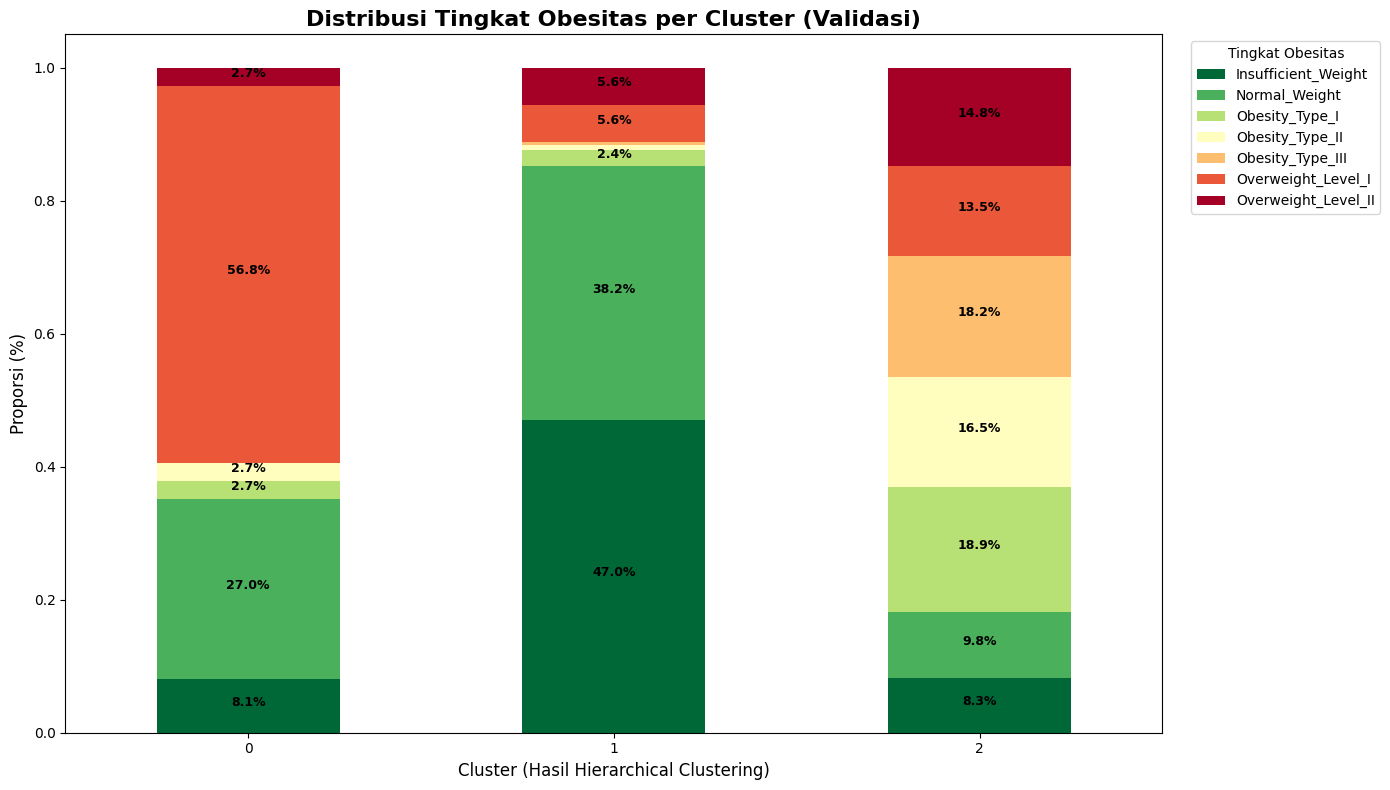

In [56]:
cross_tab = pd.crosstab(df['Cluster'], df['NObeyesdad'], normalize='index')
ax = cross_tab.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='RdYlGn_r')

plt.title('Distribusi Tingkat Obesitas per Cluster (Validasi)', fontsize=16, fontweight='bold')
plt.xlabel('Cluster (Hasil Hierarchical Clustering)', fontsize=12)
plt.ylabel('Proporsi (%)', fontsize=12)
plt.legend(title='Tingkat Obesitas', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)

# 3. Menambahkan Label Persentase di tengah batang
for n, x in enumerate([*cross_tab.index.values]):
    for (proportion, y_loc) in zip(cross_tab.loc[x], cross_tab.loc[x].cumsum()):
        # Hanya tampilkan angka jika proporsinya cukup besar (> 2%) biar gak numpuk
        if proportion > 0.02: 
            plt.text(x=n,
                     y=(y_loc - proportion) + (proportion / 2),
                     s=f'{np.round(proportion * 100, 1)}%', 
                     color="black",
                     fontsize=9,
                     fontweight="bold", 
                     ha="center")

plt.tight_layout()
plt.show()

### Visualisasi semua fitur

<Figure size 1000x800 with 0 Axes>

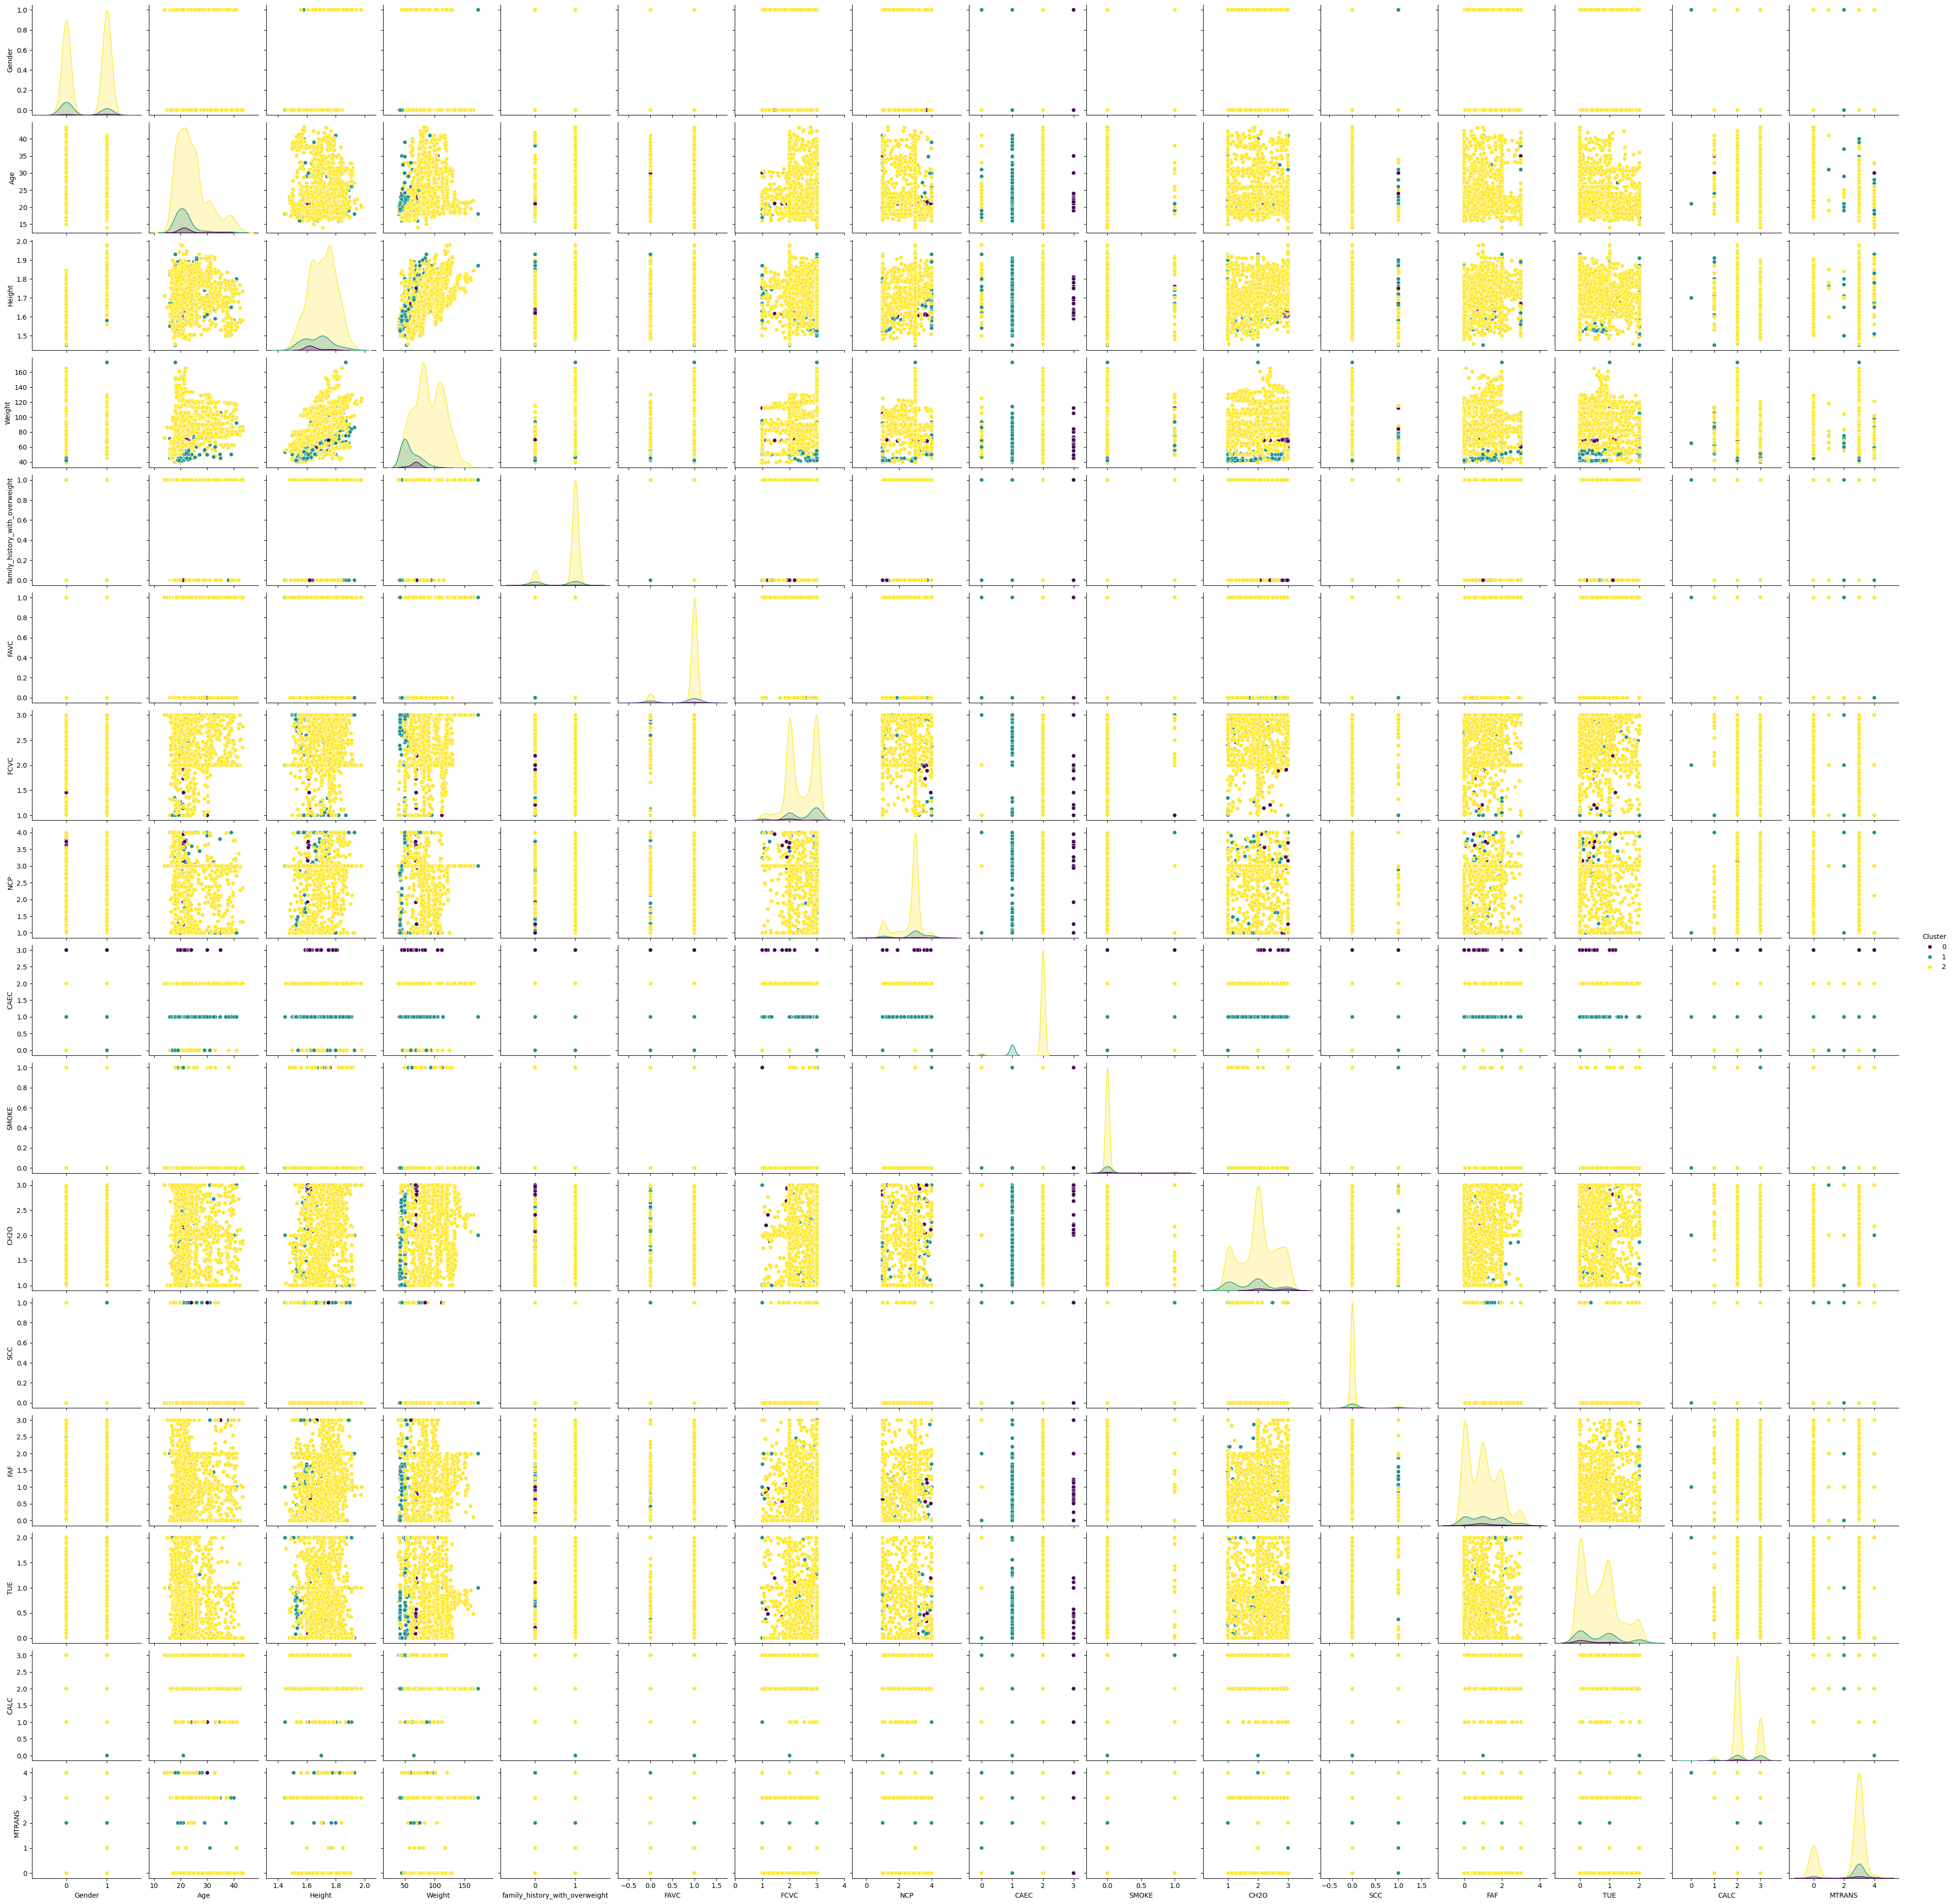

In [53]:
plt.figure(figsize=(10,8))
sns.pairplot(df, hue="Cluster", palette="viridis")
plt.show()

### Visualisasi Radar Chart

/var/folders/wm/v47lypj90l1gqzsfzt6rzn2c0000gn/T/ipykernel_25137/2140858794.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_palette = plt.cm.get_cmap("Set2", len(cluster_mean.index))


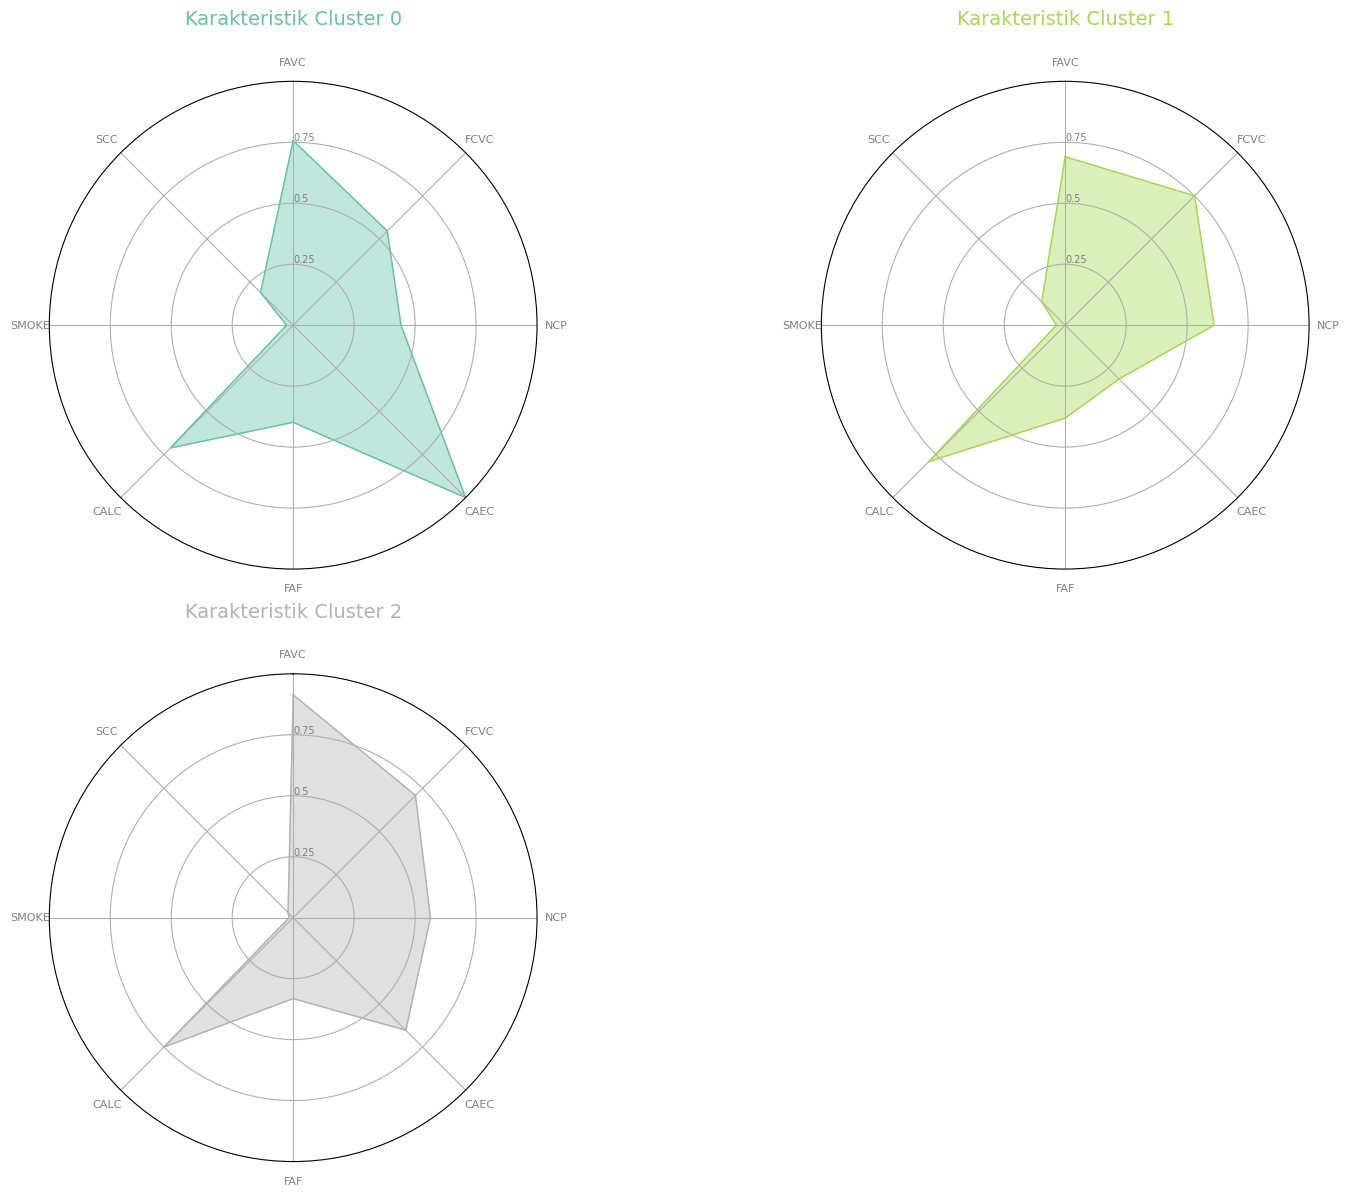

In [59]:
features_radar = ['FAVC', 'FCVC', 'NCP', 'CAEC', 'FAF', 'CALC', "SMOKE", "SCC"]

# 2. Normalisasi Data dulu (PENTING!)
# Agar skala 'Makan Sayur' (1-3) bisa dibandingkan dengan 'Olahraga' (0-3) dalam satu grafik
scaler = MinMaxScaler()
df_radar_scaled = df.copy()
df_radar_scaled[features_radar] = scaler.fit_transform(df[features_radar])

# 3. Hitung Rata-rata per 3 Cluster
cluster_mean = df_radar_scaled.groupby('Cluster')[features_radar].mean().reset_index()
# 4. Fungsi Radar Chart (Updated Layout)
def make_spider(row, title, color):
    categories = list(cluster_mean.columns[1:])
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    # -- PERUBAHAN DISINI (Layout 2x2) --
    ax = plt.subplot(2, 2, row+1, polar=True) 
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    plt.xticks(angles[:-1], categories, color='grey', size=8)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25","0.5","0.75"], color="grey", size=7)
    plt.ylim(0, 1)
    
    values = cluster_mean.loc[row].drop('Cluster').values.flatten().tolist()
    values += values[:1]
    
    ax.plot(angles, values, linewidth=1, linestyle='solid', color=color)
    ax.fill(angles, values, color=color, alpha=0.4)
    
    plt.title(title, size=14, color=color, y=1.1)

# 5. Eksekusi Plot (4 Cluster)
plt.figure(figsize=(16, 12)) # Ukuran diperbesar biar muat 4
my_palette = plt.cm.get_cmap("Set2", len(cluster_mean.index))

for i in range(len(cluster_mean.index)):
    make_spider(row=i, title=f'Karakteristik Cluster {i}', color=my_palette(i))

plt.tight_layout()
plt.show()

## Interpretasi Hasil Clustering

##  Cluster 0 : Kelompok Nyemil Banyak, Resiko Tinggi”
Cluster 0 didominasi oleh kategori Overweight Level I (56.8%) yang menunjukkan bahwa kelompok ini berada pada tahap awal peningkatan berat badan. Hal ini sejalan dengan perilaku yang tampak pada radar chart, yaitu konsumsi makanan tinggi kalori dan alkohol yang cukup tinggi, sedangkan aktivitas fisik tidak terlalu menonjol. Pola tersebut menyebabkan terjadinya surplus energi yang kemudian memicu peningkatan berat badan. Cluster ini perlu menjadi sasaran intervensi pencegahan untuk mengurangi risiko berkembang menjadi obesitas tipe I–III.

##  Cluster 1 : Kelompok Sehat, Resiko Rendah
Cluster 1 didominasi oleh Normal Weight (47%) dan sebagian Insufficient Weight, yang menunjukkan kelompok dengan risiko obesitas paling rendah. Perilaku yang tergambar di radar chart memperlihatkan konsumsi sayur yang baik, pola makan lebih teratur, dan gaya hidup yang lebih seimbang dibandingkan cluster lainnya. Hal ini menunjukkan bahwa kebiasaan hidup sehat pada cluster ini berkontribusi secara langsung terhadap pengendalian berat badan yang baik. Cluster ini dapat dijadikan dasar atau acuan pola hidup yang direkomendasikan bagi kelompok lain.

##  Cluster 2 : Kelompok Konsumsi Tinggi Kalori, Resiko Menengah
Cluster 2 memperlihatkan bahwa pola makan pada cluster ini cukup buruk karena tingginya konsumsi kalori dan kebiasaan ngemil, sementara aktivitas fisik cenderung rendah sehingga meningkatkan kemungkinan terjadinya peningkatan berat badan lebih lanjut. Cluster ini merupakan kelompok penting untuk dilakukan intervensi karena berada dalam kondisi obesitas yang bervariasi dan berpotensi berkembang menjadi lebih parah jika pola hidup tidak diperbaiki.